# Airport Operations Dataset - Complete Data Audit
Loading and preparing the dataset for passenger flow prediction model

In [23]:
import pandas as pd
import numpy as np
from datetime import datetime

# Define column names for flights (CSV has numeric indices as header)
flights_columns = [
    'flight_id', 'airline_name', 'airline_code', 'origin', 'destination',
    'scheduled_departure', 'scheduled_arrival', 'actual_departure', 'actual_arrival',
    'aircraft_type', 'aircraft_registration', 'scheduled_capacity', 'actual_capacity',
    'flight_status', 'delay_minutes', 'delay_reason', 'terminal', 'gate',
    'on_tarmac', 'passengers_boarded', 'total_seats', 'gate_assignment_time',
    'crew_ready', 'operational_status', 'on_time_percentage', 'turnaround_time_min',
    'fuel_efficiency_ratio', 'time_of_day', 'day_of_week', 'holiday_flag',
    'season', 'flight_type'
]


#Load all datasets

print("\n Loading datasets...")

# Flights: Skip numeric header row and apply column names
flights = pd.read_csv(r"D:\Passengers flow predictor\Passenger_Flow_Predictor\data\flights.csv", header=None, names=flights_columns, skiprows=1)

# Other datasets: Load normally
passengers = pd.read_csv(r"D:\Passengers flow predictor\Passenger_Flow_Predictor\data\passengers.csv")
security = pd.read_csv(r"D:\Passengers flow predictor\Passenger_Flow_Predictor\data\security_screening.csv")
baggage = pd.read_csv(r"D:\Passengers flow predictor\Passenger_Flow_Predictor\data\baggage.csv")
staff = pd.read_csv(r"D:\Passengers flow predictor\Passenger_Flow_Predictor\data\staff_shifts.csv")
gate_events = pd.read_csv(r"D:\Passengers flow predictor\Passenger_Flow_Predictor\data\gate_events.csv")
maintenance = pd.read_csv(r"D:\Passengers flow predictor\Passenger_Flow_Predictor\data/maintenance_logs.csv")
retail = pd.read_csv(r"D:\Passengers flow predictor\Passenger_Flow_Predictor\data\retail_transactions.csv")

print(f" Flights loaded: {flights.shape[0]} rows, {flights.shape[1]} columns")
print(f" Passengers: {passengers.shape[0]} rows")
print(f" Security Screening: {security.shape[0]} rows")
print(f" Baggage: {baggage.shape[0]} rows")
print(f" Staff Shifts: {staff.shape[0]} rows")
print(f" Gate Events: {gate_events.shape[0]} rows")
print(f" Maintenance Logs: {maintenance.shape[0]} rows")
print(f" Retail Transactions: {retail.shape[0]} rows")

# Parse datetime columns for flights

print("\n Parsing datetime columns...")

flights['scheduled_departure'] = pd.to_datetime(flights['scheduled_departure'])
flights['scheduled_arrival'] = pd.to_datetime(flights['scheduled_arrival'])
flights['actual_departure'] = pd.to_datetime(flights['actual_departure'])
flights['actual_arrival'] = pd.to_datetime(flights['actual_arrival'])
flights['gate_assignment_time'] = pd.to_datetime(flights['gate_assignment_time'])

print("DateTime parsing complete!")

# Calculate actual delay from timestamps 

print("\n Calculating actual delay metrics...")

# Calculate true delay in minutes from timestamp difference
flights['actual_delay_minutes'] = (
    (flights['actual_departure'] - flights['scheduled_departure']).dt.total_seconds() / 60
).astype(int)

# Note: Original 'delay_minutes' column appears to be gate/boarding delay
flights.rename(columns={'delay_minutes': 'gate_delay_minutes'}, inplace=True)

print(f" Actual delay calculated")
print(f"  - Min delay: {flights['actual_delay_minutes'].min()} minutes")
print(f"  - Max delay: {flights['actual_delay_minutes'].max()} minutes")
print(f"  - Mean delay: {flights['actual_delay_minutes'].mean():.2f} minutes")


# Add derived features for analysis

print("\n Creating derived features...")

# Flight duration (scheduled vs actual)
flights['scheduled_duration_minutes'] = (
    (flights['scheduled_arrival'] - flights['scheduled_departure']).dt.total_seconds() / 60
).astype(int)

flights['actual_duration_minutes'] = (
    (flights['actual_arrival'] - flights['actual_departure']).dt.total_seconds() / 60
).astype(int)

# Classification: On-time or delayed
flights['is_delayed'] = flights['actual_delay_minutes'] > 0

print(f" Derived features added")
print(f"  - {flights['is_delayed'].sum()} delayed flights")
print(f"  - {(~flights['is_delayed']).sum()} on-time flights")

# Summary and Quality Check

print("\n" + "="*80)
print("FLIGHTS DATA - READY FOR ANALYSIS")
print("="*80)

print(f"\n Dataset Shape: {flights.shape}")
print(f"\n Key Columns Available:")
key_cols = ['flight_id', 'airline_name', 'origin', 'destination', 
            'scheduled_departure', 'actual_departure', 'actual_delay_minutes', 
            'gate_delay_minutes', 'delay_reason', 'flight_status', 'season']
for col in key_cols:
    if col in flights.columns:
        print(f"   {col}")

print(f"\n Sample Data - First 5 Flights:")
display(flights[['flight_id', 'airline_name', 'origin', 'destination', 
                  'scheduled_departure', 'actual_departure', 'actual_delay_minutes', 
                  'delay_reason', 'is_delayed']].head())



print(f"\n Data preparation complete! Ready for passenger flow prediction model.")


 Loading datasets...
 Flights loaded: 1000 rows, 32 columns
 Passengers: 2500 rows
 Security Screening: 2500 rows
 Baggage: 2800 rows
 Staff Shifts: 600 rows
 Gate Events: 1200 rows
 Maintenance Logs: 400 rows
 Retail Transactions: 3000 rows

 Parsing datetime columns...
DateTime parsing complete!

 Calculating actual delay metrics...
 Actual delay calculated
  - Min delay: 120 minutes
  - Max delay: 600 minutes
  - Mean delay: 357.24 minutes

 Creating derived features...
 Derived features added
  - 1000 delayed flights
  - 0 on-time flights

FLIGHTS DATA - READY FOR ANALYSIS

 Dataset Shape: (1000, 36)

 Key Columns Available:
   flight_id
   airline_name
   origin
   destination
   scheduled_departure
   actual_departure
   actual_delay_minutes
   gate_delay_minutes
   delay_reason
   flight_status
   season

 Sample Data - First 5 Flights:


,flight_id,airline_name,origin,destination,scheduled_departure,actual_departure,actual_delay_minutes,delay_reason,is_delayed
0,UK-633,Vistara,DEL,SIN,2024-11-11 15:23:02,2024-11-11 17:23:02,120,ATC,True
1,BA-6017,British Airways,DEL,DXB,2024-10-05 07:49:26,2024-10-05 14:49:26,420,CREW,True
2,BA-7303,British Airways,DEL,DXB,2024-11-29 13:09:18,2024-11-29 15:09:18,120,TECH,True
3,KL-7243,KLM,DEL,MAA,2024-11-15 15:07:07,2024-11-15 22:07:07,420,WX,True
4,SG-1280,SpiceJet,DEL,KUL,2024-11-21 19:06:25,2024-11-21 23:06:25,240,WX,True



 Data preparation complete! Ready for passenger flow prediction model.


In [24]:
security_columns = [
    'screening_id', 'pnr_code', 'passenger_id', 'group_size', 'screening_timestamp',
    'flight_scheduled_departure', 'actual_departure', 'screening_status', 'contraband_detected',
    'requires_secondary', 'staff_id', 'lane_id', 'wait_time_minutes', 'is_fast_track',
    'is_staff', 'shift_id', 'throughput_ph', 'queue_length', 'lane_capacity', 'is_peak'
]

security = pd.read_csv(r"D:\Passengers flow predictor\Passenger_Flow_Predictor\data\security_screening.csv", header = None, names = security_columns, skiprows = 1)
security_df = pd.DataFrame(security)
print(security_df.head())

  screening_id     pnr_code passenger_id  group_size  screening_timestamp  \
0    SCR369386  PP-****3049       SZCC0Y           1  2024-12-03 01:26:50   
1    SCR890504  PP-****6099       G7KPR7           3  2024-10-18 22:57:57   
2    SCR702274  PP-****5183       K43VTP           7  2024-11-15 12:24:41   
3    SCR240363  PP-****2181       QJUWSB           3  2024-10-19 14:16:41   
4    SCR632408  PP-****5144       CTOQ1L           7  2024-11-17 17:50:25   

  flight_scheduled_departure     actual_departure screening_status  \
0        2024-10-28 07:40:04  2024-12-03 18:57:42            Clear   
1        2024-10-31 05:00:15  2024-12-05 17:18:25            Clear   
2        2024-11-17 23:36:49  2024-10-04 05:08:50            Clear   
3        2024-10-20 05:33:52  2024-11-11 23:03:11            Clear   
4        2024-12-27 22:03:53  2024-12-13 13:09:13            Clear   

   contraband_detected  requires_secondary   staff_id lane_id  \
0                  NaN               False  RET-0KA

In [25]:
#If we look at the security screening data, we can see that there are some key features
#that could be useful for our passenger flow prediction model. For example, the 'wait_time_minutes'
#column could help us understand how long passengers are spending in the security screening process,
#which could impact their overall flow through the airport. Additionally, the 'is_fast_track' 
#column could indicate whether certain passengers are able to bypass regular security lines, 
#which could also affect flow patterns.

#but first lets parse the screening timestamp to datetime
security["screening_timestamp"] = pd.to_datetime(security["screening_timestamp"])

#aggregate into 15 minute windows 
security_indexed = security.set_index("screening_timestamp")
security_15m = security_indexed.resample("15min").agg(
    avg_wait_time = ("wait_time_minutes", "mean"),
    max_queue_length = ("queue_length", "max"),
    passengers_cleared = ("passenger_id", "count"),
).reset_index()

security_15m.rename(columns={'screening_timestamp': 'time_window'}, inplace=True)
print(f" Security timeline created: {security_15m.shape[0]} time windows.")

# Aggregate flights by scheduled departure
flights_indexed = flights.set_index('scheduled_departure')
flights_15m = flights_indexed.resample('15min').agg(
    departing_flights_count=('flight_id', 'count'),
    upcoming_flight_capacity=('scheduled_capacity', 'sum') # Total seats leaving in this window
).reset_index()

flights_15m.rename(columns={'scheduled_departure': 'time_window'}, inplace=True)

# Shift flight data backwards by 120 minutes
flights_15m['time_window'] = flights_15m['time_window'] - pd.Timedelta(minutes=120)
print(" Flight capacity shifted backwards by 120 minutes.")

# Outer join to keep the continuous timeline even if there's a gap in data
master_df = pd.merge(security_15m, flights_15m, on='time_window', how='outer')

# Sort chronologically and fill missing values with 0
master_df = master_df.sort_values('time_window').fillna(0)

# Add standard time features for the ML model later
master_df['hour_of_day'] = master_df['time_window'].dt.hour
master_df['day_of_week'] = master_df['time_window'].dt.dayofweek

print("\n" + "="*80)
print("MASTER TIMELINE READY")
print("="*80)
print(f" Master Shape: {master_df.shape}")
print("\n Sample Data - Note how upcoming flight capacity aligns with wait times:")
display(master_df.head(10))

 Security timeline created: 8728 time windows.
 Flight capacity shifted backwards by 120 minutes.

MASTER TIMELINE READY
 Master Shape: (8731, 8)

 Sample Data - Note how upcoming flight capacity aligns with wait times:


,time_window,avg_wait_time,max_queue_length,passengers_cleared,departing_flights_count,upcoming_flight_capacity,hour_of_day,day_of_week
0,2024-09-30 23:45:00,0.0,0.0,0.0,1.0,161.0,23,0
1,2024-10-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0,1
2,2024-10-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0,1
3,2024-10-01 00:30:00,60.0,200.0,1.0,1.0,170.0,0,1
4,2024-10-01 00:45:00,60.0,200.0,2.0,0.0,0.0,0,1
5,2024-10-01 01:00:00,0.0,0.0,0.0,0.0,0.0,1,1
6,2024-10-01 01:15:00,60.0,200.0,1.0,0.0,0.0,1,1
7,2024-10-01 01:30:00,0.0,0.0,0.0,0.0,0.0,1,1
8,2024-10-01 01:45:00,60.0,200.0,1.0,0.0,0.0,1,1
9,2024-10-01 02:00:00,60.0,200.0,2.0,0.0,0.0,2,1


C:\Users\David\AppData\Local\Temp\ipykernel_24536\1462149282.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc ="upper left")


(array([19997.  , 19997.25, 19997.5 , 19997.75, 19998.  , 19998.25,
        19998.5 , 19998.75, 19999.  ]),
 [Text(19997.0, 0, '10-01 00'),
  Text(19997.25, 0, '10-01 06'),
  Text(19997.5, 0, '10-01 12'),
  Text(19997.75, 0, '10-01 18'),
  Text(19998.0, 0, '10-02 00'),
  Text(19998.25, 0, '10-02 06'),
  Text(19998.5, 0, '10-02 12'),
  Text(19998.75, 0, '10-02 18'),
  Text(19999.0, 0, '10-03 00')])

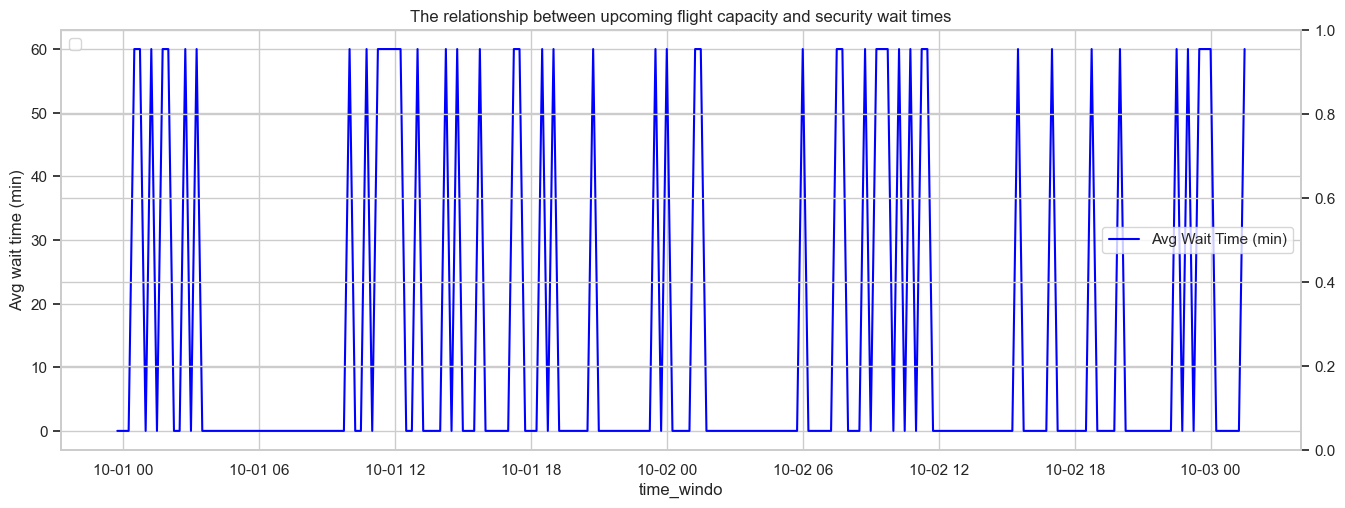

In [26]:
import matplotlib.pyplot as plt 
import seaborn as sns 

sns.set_theme(style = "whitegrid")
plt.figure(figsize=(16,12))

plt.subplot(2,1,1)

ax1 = plt.gca()
ax2 = ax1.twinx()

sns.lineplot(data = master_df.head(200), x = "time_window", y = "avg_wait_time", ax = ax1, label = "Avg Wait Time (min)", color = "blue")
ax1.set_title("The relationship between upcoming flight capacity and security wait times")
ax1.set_xlabel("time_windo")
ax1.set_ylabel("Avg wait time (min)")
plt.legend(loc ="upper left")
plt.xticks(rotation = 45)



Text(47.25, 0.5, 'Day of the week')

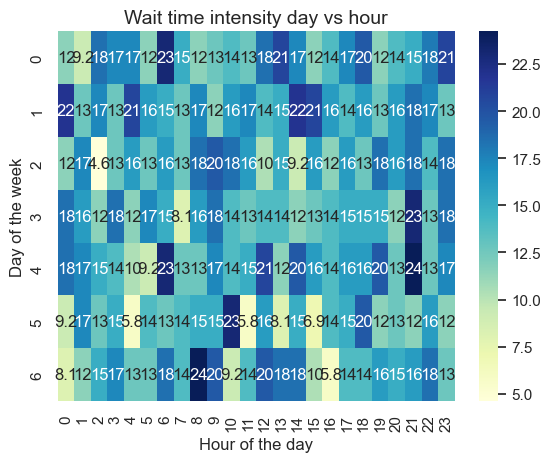

In [27]:

# pivot the data for the heatmap 
pivot_df = master_df.groupby(["day_of_week", "hour_of_day"])["avg_wait_time"].mean().unstack()

sns.heatmap(pivot_df, annot = True, cmap = "YlGnBu")
plt.title("Wait time intensity day vs hour", fontsize = 14)
plt.xlabel("Hour of the day") 
plt.ylabel("Day of the week") #0 = Monday, 6 = Sunday


Unique Wait Times: 2
Wait Time Variance: 25.975302697011635

--- NEW CORRELATION MATRIX (Target = Passenger Flow) ---


,target_flow,upcoming_flight_capacity,hour_of_day
target_flow,1.000000,0.011086,0.016304
upcoming_flight_capacity,0.011086,1.000000,-0.011453
hour_of_day,0.016304,-0.011453,1.000000


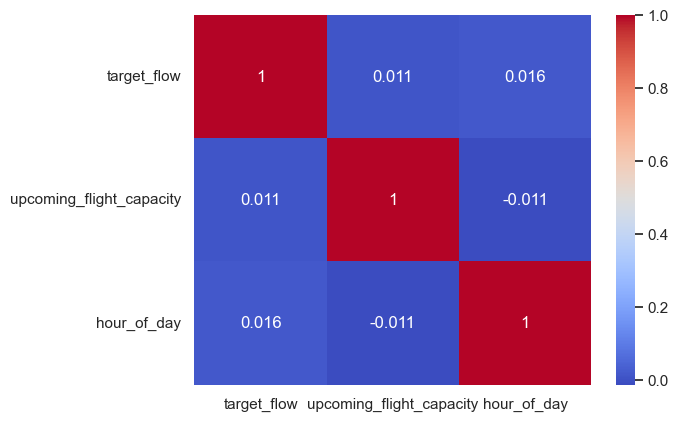

In [28]:
# Check how many unique values are in our target
print(f"Unique Wait Times: {master_df['avg_wait_time'].nunique()}")
print(f"Wait Time Variance: {master_df['avg_wait_time'].std()}")

if master_df['avg_wait_time'].std() == 0:
    print("\n WARNING: Wait Time is constant. Switching to 'Passenger Flow' as the target.")
    # Use the count of passengers as our new target for the correlation check
    master_df['target_flow'] = master_df['passengers_cleared']
else:
    master_df['target_flow'] = master_df['avg_wait_time']

# Now re-run a simplified correlation
flow_corr = master_df[['target_flow', 'upcoming_flight_capacity', 'hour_of_day']].corr()
sns.heatmap(flow_corr, annot = True, cmap = "coolwarm")
print("\n--- NEW CORRELATION MATRIX (Target = Passenger Flow) ---")
display(flow_corr)

Loading Baggage Data...
Loading Staff Shifts...


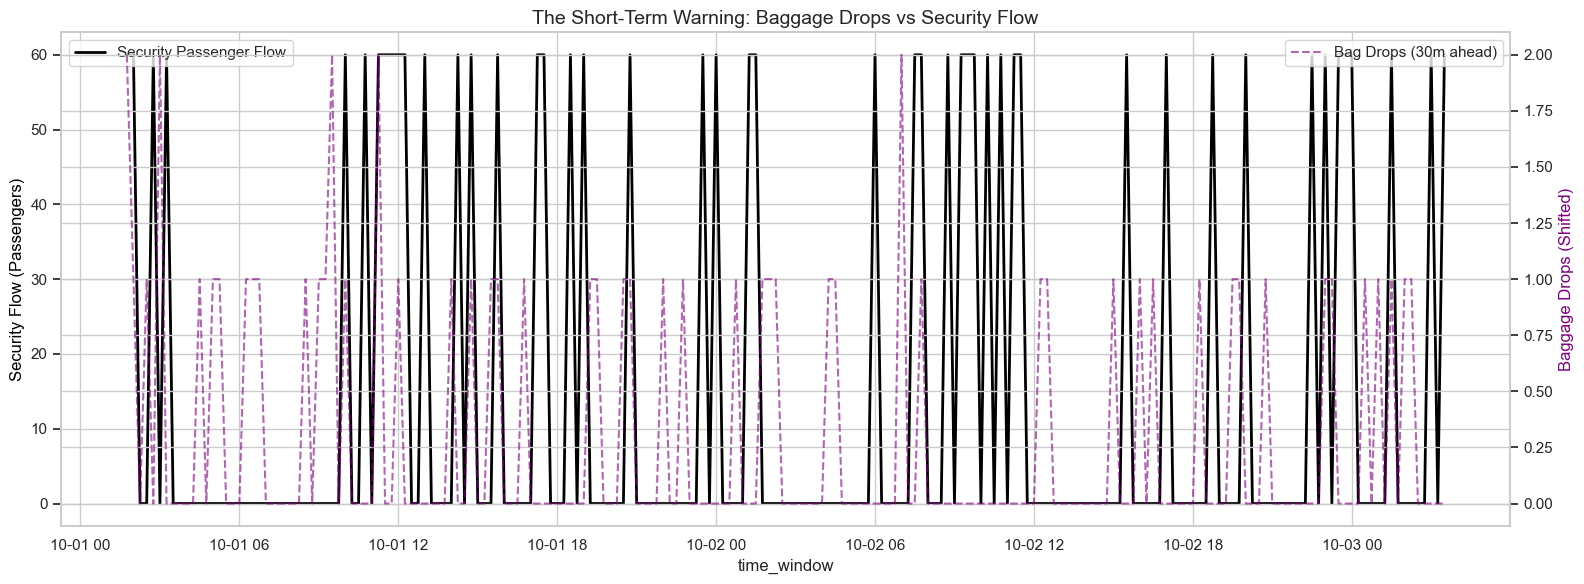

EDA Complete! Check the plots.


In [29]:
# Process baggag data
print("Loading Baggage Data...")
baggage_cols = [
    'baggage_id', 'pnr_code', 'flight_id', 'passenger_id', 'weight_kg', 
    'dimensions', 'status', 'location', 'checkin_timestamp', 'loaded_timestamp', 
    'belt_id', 'handling_status', 'is_fragile', 'num_scans', 'last_scan_location', 
    'last_scan_time', 'is_delayed'
]
baggage = pd.read_csv(r"D:\Passengers flow predictor\Passenger_Flow_Predictor\data\baggage.csv", header = None, names = baggage_cols, skiprows = 1)

# Parse time and resample to 15 minute windows
baggage["checkin_timestamp"] = pd.to_datetime(baggage["checkin_timestamp"])
baggage_15m = baggage.set_index('checkin_timestamp').resample('15min').agg(
    bag_drops=('baggage_id', 'count')
).reset_index().rename(columns={'checkin_timestamp': 'time_window'})

# We shift baggage by 30 minutes! (Bags dropped at 8:00 mean people at security at 8:30)
baggage_15m['time_window'] = baggage_15m['time_window'] + pd.Timedelta(minutes=30)

print("Loading Staff Shifts...")
staff_cols = [
    'staff_id', 'name', 'department', 'role', 'shift_date', 'shift_start', 
    'shift_end', 'terminal', 'zone', 'supervisor_id', 'hours', 'is_overtime', 
    'notes', 'hire_date', 'language'
]
staff = pd.read_csv(r"D:\Passengers flow predictor\Passenger_Flow_Predictor\data\staff_shifts.csv", header=None, names=staff_cols, skiprows=1)

staff['shift_start'] = pd.to_datetime(staff['shift_start'])
staff['shift_end'] = pd.to_datetime(staff['shift_end'])

# To count active staff per 15-minute window, we need to check overlapping times
# For speed in EDA, we will just count how many shifts START in a given hour
staff_hourly = staff.set_index('shift_start').resample('h').agg(
    staff_starting_shift=('staff_id', 'count')
).reset_index().rename(columns={'shift_start': 'time_window'})

# Merge with master_df
advanced_df = pd.merge(master_df, baggage_15m, on='time_window', how='inner')

#visualizing 
sns.set_theme(style = "whitegrid")
plt.figure(figsize = (16,6))
ax1 = plt.gca()
ax2 = ax1.twinx()

# Plot Security Flow (Target)
sns.lineplot(data=advanced_df.head(200), x='time_window', y='target_flow', 
             ax=ax1, color='black', linewidth=2, label='Security Passenger Flow')

# Plot Baggage Drops (Shifted by 30 mins)
sns.lineplot(data=advanced_df.head(200), x='time_window', y='bag_drops', 
             ax=ax2, color='purple', alpha=0.6, linestyle='dashed', label='Bag Drops (30m ahead)')

ax1.set_title("The Short-Term Warning: Baggage Drops vs Security Flow", fontsize=14)
ax1.set_ylabel("Security Flow (Passengers)", color='black')
ax2.set_ylabel("Baggage Drops (Shifted)", color='purple')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("EDA Complete! Check the plots.")